<a href="https://colab.research.google.com/github/Gaddy01/Intro_to_ML-Summative/blob/main/Intro_to_ML_Sumative_Gaddiel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Mission and Dataset Relevance

This project aligns with my mission of leveraging Machine Learning and Artificial Intelligence to promote public health and support the prevention of lifestyle-related diseases. As the prevalence of conditions such as obesity, diabetes, and cardiovascular diseases continues to increase worldwide, there is a growing need for data-driven tools that can help identify risk factors and encourage healthier behaviors. The dataset used in this project contains information related to individuals' eating habits, physical activity, water consumption, family history, and other lifestyle factors that are closely associated with obesity levels.

By analyzing these patterns and developing predictive models, this project demonstrates how Machine Learning can be used to identify individuals at risk of obesity and support early intervention strategies. Since obesity is a major risk factor for numerous chronic diseases, including type 2 diabetes, the insights generated from this work contribute to the broader goal of improving health outcomes and promoting preventive healthcare through technology.

Data source: https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay, roc_auc_score, roc_curve, recall_score, precision_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, Callback

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
!pip install ucimlrepo

In [17]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition = fetch_ucirepo(id=544)
# data (as pandas dataframes)
X = estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition.data.features
y = estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition.data.targets

# metadata
#print(estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition.metadata)
# variable information
print(estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition.variables)


                              name     role         type demographic  \
0                           Gender  Feature  Categorical      Gender   
1                              Age  Feature   Continuous         Age   
2                           Height  Feature   Continuous        None   
3                           Weight  Feature   Continuous        None   
4   family_history_with_overweight  Feature       Binary        None   
5                             FAVC  Feature       Binary        None   
6                             FCVC  Feature      Integer        None   
7                              NCP  Feature   Continuous        None   
8                             CAEC  Feature  Categorical        None   
9                            SMOKE  Feature       Binary        None   
10                            CH2O  Feature   Continuous        None   
11                             SCC  Feature       Binary        None   
12                             FAF  Feature   Continuous        

In [18]:
X.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation


## Features Engineering

In [19]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

### Binary Encoding of Categorical Features

Several features in this dataset contain only two possible categories (e.g., *Male/Female* or *Yes/No*). To prepare these variables for machine learning algorithms, binary encoding is applied by converting each category into a numerical representation (0 or 1). This transformation preserves the original information while making the data compatible with mathematical operations performed by machine learning models. Additionally, binary encoding reduces computational complexity and avoids introducing unnecessary extra features compared to one-hot encoding for variables with only two categories.


In [20]:
X["Gender"].unique()

array(['Female', 'Male'], dtype=object)

In [21]:
X["family_history_with_overweight"].unique()

array(['yes', 'no'], dtype=object)

In [22]:
X["FAVC"].unique()

array(['no', 'yes'], dtype=object)

In [23]:
X["SMOKE"].unique()

array(['no', 'yes'], dtype=object)

In [24]:
X["SCC"].unique()

array(['no', 'yes'], dtype=object)

In [25]:
binary_mapping = {
    "no": 0,
    "yes": 1
    }

X["Gender"] = X["Gender"].map({"Female": 0, "Male": 1})
X["family_history_with_overweight"] = X["family_history_with_overweight"].map(binary_mapping)
X["FAVC"] = X["FAVC"].map(binary_mapping)
X["SMOKE"] = X["SMOKE"].map(binary_mapping)
X["SCC"] = X["SCC"].map(binary_mapping)

### Ordinal Encoding of Ordered Categorical Features

Some categorical features in the dataset have a natural order between their categories (e.g., *no*, *Sometimes*, *Frequently*, *Always*). For these variables, ordinal encoding is applied by assigning increasing numerical values that reflect the inherent ranking of the categories. This approach preserves the ordinal relationships present in the data while converting the features into a numerical format that can be effectively processed by machine learning algorithms.


In [28]:
X["CAEC"].unique()

array(['Sometimes', 'Frequently', 'Always', 'no'], dtype=object)

In [29]:
X["CALC"].unique()

array(['no', 'Sometimes', 'Frequently', 'Always'], dtype=object)

In [30]:
mapping = {
    "no": 0,
    "Sometimes": 1,
    "Frequently": 2,
    "Always": 3
}

X["CAEC"] = X["CAEC"].map(mapping)
X["CALC"] = X["CALC"].map(mapping)

### One-Hot Encoding of Nominal Categorical Features

Some categorical features contain multiple categories without any natural order or ranking between them. For these variables, one-hot encoding is applied by creating a separate binary feature for each category. This transformation converts categorical data into a numerical format suitable for machine learning algorithms while preventing the model from incorrectly interpreting arbitrary numerical labels as meaningful rankings or relationships between categories.

In [33]:
X["MTRANS"].unique()

array(['Public_Transportation', 'Walking', 'Automobile', 'Motorbike',
       'Bike'], dtype=object)

In [34]:
X = pd.get_dummies(X, columns=["MTRANS"], drop_first=False)

In [39]:
X.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,0,21.0,1.62,64.0,1,0,2.0,3.0,1,0,2.0,0,0.0,1.0,0,False,False,False,True,False
1,0,21.0,1.52,56.0,1,0,3.0,3.0,1,1,3.0,1,3.0,0.0,1,False,False,False,True,False
2,1,23.0,1.80,77.0,1,0,2.0,3.0,1,0,2.0,0,2.0,1.0,2,False,False,False,True,False
3,1,27.0,1.80,87.0,0,0,3.0,3.0,1,0,2.0,0,2.0,0.0,2,False,False,False,False,True
4,1,22.0,1.78,89.8,0,0,2.0,1.0,1,0,2.0,0,0.0,0.0,1,False,False,False,True,False


### Retaining Numerical Features

Features that are already represented as numerical values are retained in their original format, as they contain meaningful quantitative information that can be directly utilized by machine learning algorithms. Keeping these variables unchanged preserves the magnitude and variation present in the data, allowing the model to learn patterns and relationships without introducing unnecessary transformations.

This is suitable for features such as **Age, Height, Weight, FCVC, NCP, CH2O, FAF**, and **TUE**, which already provide numerical measurements or frequencies that can be used directly during model training.

Regarding **the target feature**, it must be transformed, because it is a categorical label and most classification algorithms require numeric target values.

In [35]:
y.head()

,NObeyesdad
0,Normal_Weight
1,Normal_Weight
2,Normal_Weight
3,Overweight_Level_I
4,Overweight_Level_II


In [36]:
y["NObeyesdad"].unique()

array(['Normal_Weight', 'Overweight_Level_I', 'Overweight_Level_II',
       'Obesity_Type_I', 'Insufficient_Weight', 'Obesity_Type_II',
       'Obesity_Type_III'], dtype=object)

In [37]:
mapping = {
    "Insufficient_Weight": 0,
    "Normal_Weight": 1,
    "Overweight_Level_I": 2,
    "Overweight_Level_II": 3,
    "Obesity_Type_I": 4,
    "Obesity_Type_II": 5,
    "Obesity_Type_III": 6
}

y["NObeyesdad"] = y["NObeyesdad"].map(mapping)

In [38]:
y.head()

,NObeyesdad
0,1
1,1
2,1
3,2
4,3


In [40]:
y["NObeyesdad"].unique()

array([1, 2, 3, 4, 0, 5, 6])

## ML models development and training

In [41]:
def train_random_forest_with_grid_search(X, y, test_size=0.2, max_depth=None):

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)

    # Apply StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Create a RandomForestClassifier model
    rf = RandomForestClassifier(random_state=42)

    # Define parameter grid for GridSearchCV
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_features': ['sqrt', None]
    }

    # Set max_depth based on user input
    if max_depth is None:
        param_grid['max_depth'] = [10, 20] # Explore some common depth values
    else:
        param_grid['max_depth'] = [max_depth]

    # Initialize and fit GridSearchCV
    # Using y.values.ravel() to ensure y is in the correct 1D format for scikit-learn
    grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
    grid_search.fit(X_train_scaled, y_train.values.ravel())

    return grid_search.best_estimator_, grid_search.best_params_, grid_search.best_score_, X_train_scaled, y_train, X_test_scaled, y_test

In [42]:
def plot_learning_curve(best_estimator, X_train_scaled, y_train, scoring='accuracy'):
    train_sizes, train_scores, test_scores = learning_curve(
        best_estimator, X_train_scaled, y_train.values.ravel(), cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10), scoring=scoring
    )

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    fig_lc, ax_lc = plt.subplots(figsize=(5, 4))
    ax_lc.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    ax_lc.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1,
                     color="g")
    ax_lc.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    ax_lc.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Cross-validation score")
    ax_lc.set_title('Learning Curves')
    ax_lc.set_xlabel('Training examples')
    ax_lc.set_ylabel('Score')
    ax_lc.legend(loc="best")
    plt.grid(True)
    plt.tight_layout() # Adjust layout to prevent labels from being cut off
    plt.show()

def plot_roc_curve(best_estimator, X_test_scaled, y_test, class_names):
    y_proba = best_estimator.predict_proba(X_test_scaled)

    if hasattr(best_estimator, "decision_function"):
        y_score = best_estimator.decision_function(X_test_scaled)
    else:
        y_score = y_proba

    from sklearn.preprocessing import label_binarize
    n_classes = len(class_names)
    y_test_binarized = label_binarize(y_test, classes=range(n_classes))

    if n_classes > 2:
        fpr, tpr, _ = roc_curve(y_test_binarized.ravel(), y_score.ravel())
        roc_auc = roc_auc_score(y_test_binarized, y_score, multi_class='ovr')
        plt.figure(figsize=(5, 4))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Micro-average ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic (ROC) Curve (Micro-average)')
        plt.legend(loc="lower right")
        plt.tight_layout()
        plt.show()
    elif n_classes == 2:
        fpr, tpr, _ = roc_curve(y_test, y_proba[:, 1])
        roc_auc = roc_auc_score(y_test, y_proba[:, 1])
        plt.figure(figsize=(5, 4))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic (ROC) Curve')
        plt.legend(loc="lower right")
        plt.tight_layout()
        plt.show()
    else:
        print("ROC curve not applicable for a single class.")

def evaluate_model(best_estimator, X_test_scaled, y_test, class_names):

    # Make predictions
    y_pred = best_estimator.predict(X_test_scaled)

    # 1. Print Accuracy and Classification Report
    print("\n--- Model Evaluation ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=class_names))

    # 2. Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig_cm, ax_cm = plt.subplots(figsize=(7, 7))
    disp.plot(cmap=plt.cm.Blues, ax=ax_cm)
    ax_cm.set_title('Confusion Matrix')
    plt.xticks(rotation=90) # Rotate x-axis labels
    plt.tight_layout() # Adjust layout to prevent labels from being cut off
    plt.show()

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Parameters: {'max_depth': 8, 'max_features': None, 'n_estimators': 300}
Best Cross-validation Accuracy: 0.9384

--- Model Evaluation ---
Accuracy: 0.9338

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.89      0.93        54
      Normal_Weight       0.83      0.86      0.85        58
 Overweight_Level_I       0.86      0.86      0.86        58
Overweight_Level_II       0.93      0.97      0.95        58
     Obesity_Type_I       0.95      0.99      0.97        70
    Obesity_Type_II       1.00      0.97      0.98        60
   Obesity_Type_III       0.98      0.98      0.98        65

           accuracy                           0.93       423
          macro avg       0.93      0.93      0.93       423
       weighted avg       0.94      0.93      0.93       423



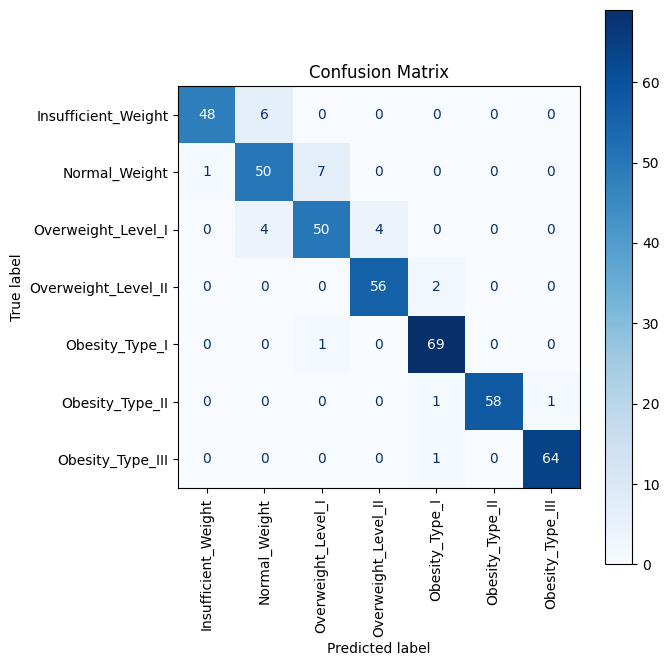

In [ ]:
class_names = [k for k, v in sorted(mapping.items(), key=lambda item: item[1])]

# Run the training function with max_depth=8
best_estimator, best_params, best_score, X_train_scaled, y_train, X_test_scaled, y_test = train_random_forest_with_grid_search(X, y, max_depth=8)

print(f"Best Parameters: {best_params}")
print(f"Best Cross-validation Accuracy: {best_score:.4f}")

# Run the evaluation function
evaluate_model(best_estimator, X_test_scaled, y_test, class_names)

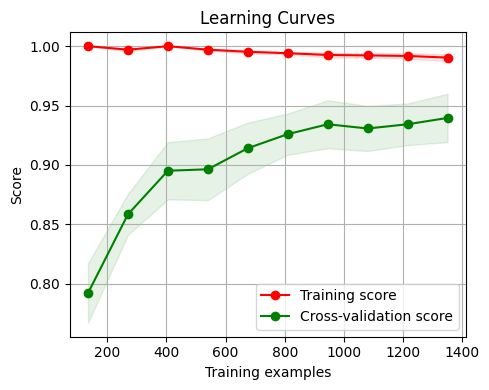

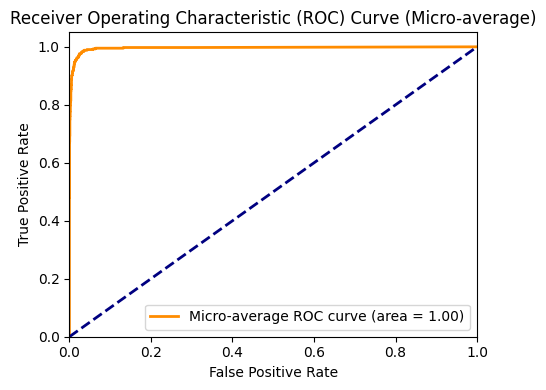

In [ ]:
# 3. Learning Curves
plot_learning_curve(best_estimator, X_train_scaled, y_train)
# 4. ROC Curve
plot_roc_curve(best_estimator, X_test_scaled, y_test, class_names)

### Interpretation of Random Forest Model with `max_depth=8`

The initial Random Forest model, with `max_depth=8`, achieved a cross-validation accuracy of **0.9384** and a test accuracy of **0.9338**. This indicates strong performance in classifying obesity levels.

Looking at the classification report, the model shows high precision, recall, and f1-scores across most obesity levels, particularly for 'Insufficient_Weight', 'Obesity_Type_I', 'Obesity_Type_II', and 'Obesity_Type_III', where scores are 0.95 or higher. 'Normal_Weight' and 'Overweight_Level_I' have slightly lower, but still respectable, scores around 0.85-0.86, suggesting a bit more confusion among these categories. Overall, the model demonstrates good generalization capabilities with these hyperparameters.

### Rationale for Increasing `max_depth` to 12

Although the first model with `max_depth=8` performed well, there's a possibility that the model might be underfitting slightly, meaning it hasn't fully captured all the complexities in the data.

To explore if a more complex model can achieve even higher accuracy, we're going to increase `max_depth` to 12,

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Parameters: {'max_depth': 12, 'max_features': None, 'n_estimators': 300}
Best Cross-validation Accuracy: 0.9508

--- Model Evaluation ---
Accuracy: 0.9480

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.89      0.93        54
      Normal_Weight       0.85      0.95      0.89        58
 Overweight_Level_I       0.94      0.86      0.90        58
Overweight_Level_II       0.93      0.98      0.96        58
     Obesity_Type_I       0.96      0.99      0.97        70
    Obesity_Type_II       1.00      0.97      0.98        60
   Obesity_Type_III       0.98      0.98      0.98        65

           accuracy                           0.95       423
          macro avg       0.95      0.95      0.95       423
       weighted avg       0.95      0.95      0.95       423



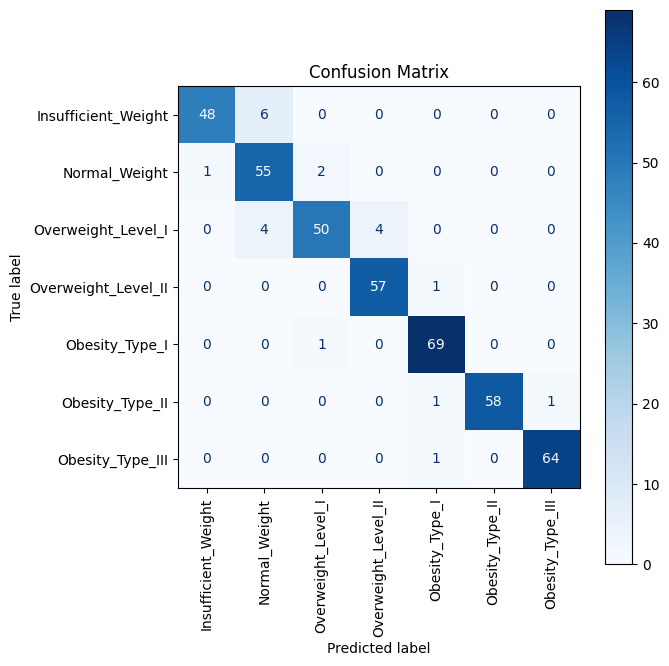

In [ ]:
class_names = [k for k, v in sorted(mapping.items(), key=lambda item: item[1])]

# Run the training function with max_depth=8
best_estimator, best_params, best_score, X_train_scaled, y_train, X_test_scaled, y_test = train_random_forest_with_grid_search(X, y, max_depth=12)

print(f"Best Parameters: {best_params}")
print(f"Best Cross-validation Accuracy: {best_score:.4f}")

# Run the evaluation function
evaluate_model(best_estimator, X_test_scaled, y_test, class_names)

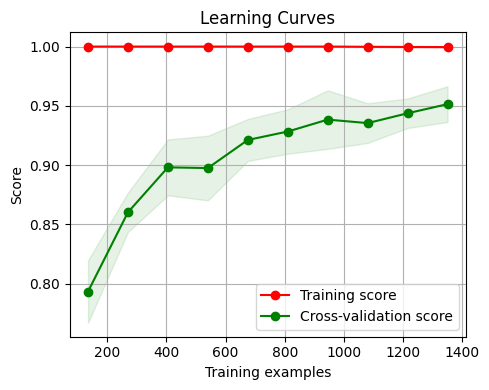

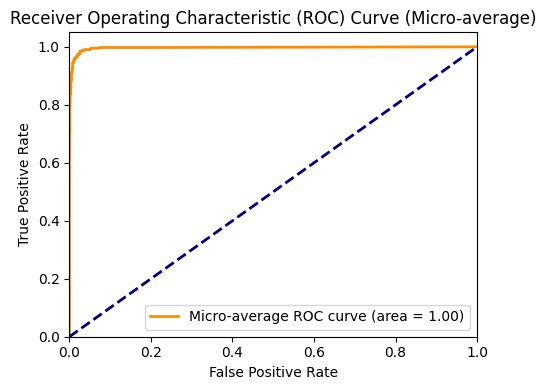

In [ ]:
# 3. Learning Curves
plot_learning_curve(best_estimator, X_train_scaled, y_train)
# 4. ROC Curve
plot_roc_curve(best_estimator, X_test_scaled, y_test, class_names)

### Interpretation of Random Forest Model with `max_depth=12`

Increasing `max_depth` to 12 significantly improved the Random Forest model's performance, achieving a Best Cross-validation Accuracy of **0.9508** and a test Accuracy of **0.9480**. This indicates that allowing trees to grow deeper enabled the model to capture more complex patterns.

The Classification Report shows enhanced performance, especially for 'Normal_Weight' and 'Overweight_Level_I', which saw improvements in recall and f1-scores. The model maintained excellent precision, recall, and f1-scores for 'Insufficient_Weight', 'Obesity_Type_II', and 'Obesity_Type_III'. Overall, the increase in `max_depth` was beneficial, leading to a more accurate and robust model without signs of overfitting, as both CV and test accuracies are high and consistent.

### Rationale for increasing `max_depth` to 15

Let's now use a max_depth of 15 and see what happens. Let's if the model performance increases, or if au contraire, the model perfomnce decreases because of overfitting.

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Parameters: {'max_depth': 15, 'max_features': None, 'n_estimators': 300}
Best Cross-validation Accuracy: 0.9508

--- Model Evaluation ---
Accuracy: 0.9480

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.89      0.93        54
      Normal_Weight       0.85      0.95      0.89        58
 Overweight_Level_I       0.94      0.86      0.90        58
Overweight_Level_II       0.93      0.98      0.96        58
     Obesity_Type_I       0.96      0.99      0.97        70
    Obesity_Type_II       1.00      0.97      0.98        60
   Obesity_Type_III       0.98      0.98      0.98        65

           accuracy                           0.95       423
          macro avg       0.95      0.95      0.95       423
       weighted avg       0.95      0.95      0.95       423



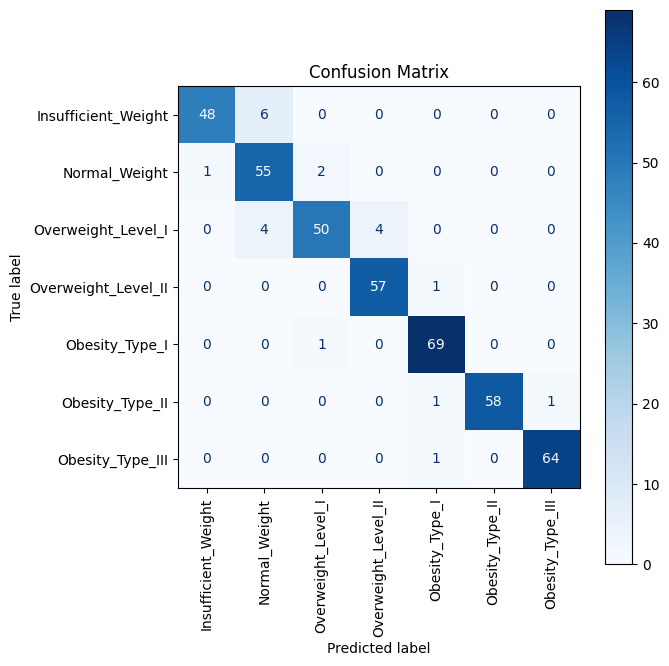

In [45]:
class_names = [k for k, v in sorted(mapping.items(), key=lambda item: item[1])]

# Run the training function with max_depth=8
best_estimator, best_params, best_score, X_train_scaled, y_train, X_test_scaled, y_test = train_random_forest_with_grid_search(X, y, max_depth=15)

print(f"Best Parameters: {best_params}")
print(f"Best Cross-validation Accuracy: {best_score:.4f}")

# Run the evaluation function
evaluate_model(best_estimator, X_test_scaled, y_test, class_names)

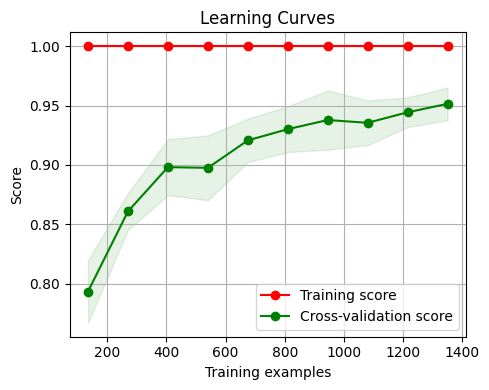

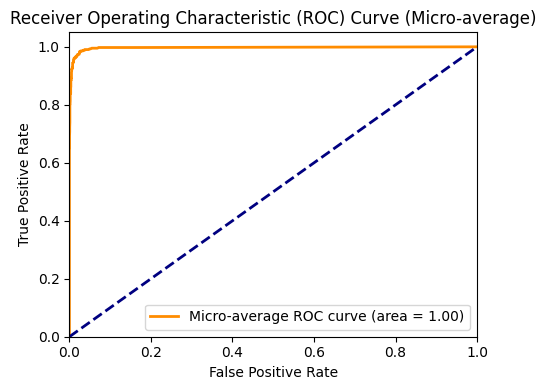

In [46]:
# 3. Learning Curves
plot_learning_curve(best_estimator, X_train_scaled, y_train)
# 4. ROC Curve
plot_roc_curve(best_estimator, X_test_scaled, y_test, class_names)

Athough the model did not overfit, we notice that its perofrmance did not increase when we increased the max_depth from 12 to 15. Therefore, we're gonna stay with **12 as our final max depth value.**

## DL Models development and training

In [47]:
# Custom callback to print additional metrics per epoch
class MetricsCallback(Callback):
    def __init__(self, X_val, y_val):
        super().__init__()
        self.X_val = X_val
        self.y_val = y_val

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_pred_probs = self.model.predict(self.X_val, verbose=0)
        val_pred_labels = np.argmax(val_pred_probs, axis=1)

        # Ensure y_val is 1D for sklearn metrics
        y_val_1d = self.y_val.values.ravel() if isinstance(self.y_val, pd.DataFrame) else self.y_val

        # Accuracy is already tracked by Keras and available in logs
        val_accuracy = logs.get('val_accuracy')

        # Calculate other metrics
        try:
            # roc_auc_score for multi-class: uses 'ovr' strategy with integer labels and probabilities
            val_auc = roc_auc_score(y_val_1d, val_pred_probs, multi_class='ovr', average='weighted')
        except ValueError as e:
            # Handle cases where AUC cannot be computed (e.g., only one class in y_val/pred)
            val_auc = np.nan
            # print(f"Warning: Could not calculate AUC. {e}") # Uncomment for debugging

        # Precision and Recall (weighted average)
        val_precision = precision_score(y_val_1d, val_pred_labels, average='weighted', zero_division=0)
        val_recall = recall_score(y_val_1d, val_pred_labels, average='weighted', zero_division=0)

        print(f"Epoch {epoch+1}: "
              f"Train Acc: {logs.get('accuracy'):.4f}, "
              f"Val Acc: {val_accuracy:.4f}, "
              f"Val AUC: {val_auc:.4f}, "
              f"Val Precision: {val_precision:.4f}, "
              f"Val Recall: {val_recall:.4f}")


def create_and_train_ann(X_train, y_train, X_test, y_test,
                         num_hidden_layers=1, units_per_layer=64,
                         epochs=10, learning_rate=0.001, batch_size=32):

    input_dim = X_train.shape[1]
    # Determine output dimension from unique classes in y_train
    num_classes = len(np.unique(y_train))

    # 1. Create the model
    model = Sequential()
    model.add(Dense(units_per_layer, activation='relu', input_shape=(input_dim,)))

    for _ in range(num_hidden_layers - 1): # If num_hidden_layers is 1, this loop won't run.
        model.add(Dense(int(units_per_layer/2), activation='relu'))

    # Output layer with softmax activation for multi-class classification
    model.add(Dense(num_classes, activation='softmax'))

    # 2. Compile the model
    optimizer = Adam(learning_rate=learning_rate)
    # Use sparse_categorical_crossentropy for integer-encoded labels
    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy']) # Keras will track accuracy, our callback adds others

    # 3. Print the model architecture
    print("--- Model Architecture ---")
    model.summary()
    print("\n")

    # 4. Early Stopping callback
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    # 5. Custom Metrics Callback to print AUC, Precision, Recall per epoch
    metrics_callback = MetricsCallback(X_test, y_test)

    # Convert y_train and y_test to 1D numpy arrays if they are DataFrames, for model.fit
    y_train_arr = y_train.values.ravel() if isinstance(y_train, pd.DataFrame) else y_train
    y_test_arr = y_test.values.ravel() if isinstance(y_test, pd.DataFrame) else y_test

    print("--- Model Training ---")
    history = model.fit(X_train, y_train_arr,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_data=(X_test, y_test_arr),
                        callbacks=[early_stopping, metrics_callback],
                        verbose=0) # Set verbose to 0 to let custom callback handle printing

    print("\n--- Training Complete ---")
    return history, model

### ANN Model Evaluation Functions

In [48]:
def evaluate_ann_model(ann_model, X_test_scaled, y_test, class_names):

    print("\n--- ANN Model Evaluation ---")
    # For ANN, predictions are probabilities, need to convert to class labels
    y_pred_proba = ann_model.predict(X_test_scaled, verbose=0)
    y_pred_labels = np.argmax(y_pred_proba, axis=1)

    # Ensure y_test is 1D for sklearn metrics if it's a DataFrame
    y_test_1d = y_test.values.ravel() if isinstance(y_test, pd.DataFrame) else y_test

    print(f"Accuracy: {accuracy_score(y_test_1d, y_pred_labels):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test_1d, y_pred_labels, target_names=class_names))

    # Confusion Matrix
    cm = confusion_matrix(y_test_1d, y_pred_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig_cm, ax_cm = plt.subplots(figsize=(7, 7))
    disp.plot(cmap=plt.cm.Blues, ax=ax_cm)
    ax_cm.set_title('Confusion Matrix for ANN')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

In [49]:
def plot_ann_learning_curve(history):
    """ history: The Keras History object returned by model.fit().
    """
    # Plot training & validation accuracy values
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    ax1.plot(history.history['accuracy'])
    ax1.plot(history.history['val_accuracy'])
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='upper left')
    ax1.grid(True)

    # Plot training & validation loss values
    ax2.plot(history.history['loss'])
    ax2.plot(history.history['val_loss'])
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper left')
    ax2.grid(True)

    plt.tight_layout()
    plt.show()


def plot_ann_roc_curve(ann_model, X_test_scaled, y_test, class_names):

    y_proba = ann_model.predict(X_test_scaled, verbose=0)

    # Ensure y_test is 1D for sklearn metrics if it's a DataFrame
    y_test_1d = y_test.values.ravel() if isinstance(y_test, pd.DataFrame) else y_test

    n_classes = len(class_names)
    y_test_binarized = label_binarize(y_test_1d, classes=range(n_classes))

    if n_classes > 2:
        # For multi-class, compute micro-average ROC curve
        fpr, tpr, _ = roc_curve(y_test_binarized.ravel(), y_proba.ravel())
        roc_auc = roc_auc_score(y_test_binarized, y_proba, multi_class='ovr', average='micro')

        plt.figure(figsize=(5, 5))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Micro-average ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic (ROC) Curve (Micro-average) for ANN')
        plt.legend(loc="lower right")
        plt.tight_layout()
        plt.show()
    elif n_classes == 2:
        # For binary classification
        fpr, tpr, _ = roc_curve(y_test_1d, y_proba[:, 1])
        roc_auc = roc_auc_score(y_test_1d, y_proba[:, 1])

        plt.figure(figsize=(5, 5))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic (ROC) Curve for ANN')
        plt.legend(loc="lower right")
        plt.tight_layout()
        plt.show()
    else:
        print("ROC curve not applicable for a single class.")

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Rationale for Initial ANN Model Parameters

We start with a baseline ANN model using common default parameters to establish a comparison point and incrementally optimize. The initial parameters are chosen for simplicity and balance:

*   **`num_hidden_layers=1`**: Simple starting point, reducible complexity.
*   **`units_per_layer=64`**: Moderate units for capacity and computational cost.
*   **`epochs=10`**: Quick assessment of learning ability; to be increased if promising.
*   **`learning_rate=0.001`**: Standard Adam optimizer default, good for speed and stability.
*   **`batch_size=32`**: Common choice balancing stability and regularization.

In [ ]:
print("Training the ANN with default parameters:")
history, ann_model = create_and_train_ann(X_train_scaled, y_train, X_test_scaled, y_test)

Training the ANN with default parameters:
--- Model Architecture ---


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,799 (7.03 KB)

 Trainable params: 1,799 (7.03 KB)

 Non-trainable params: 0 (0.00 B)



--- Model Training ---
Epoch 1: Train Acc: 0.4236, Val Acc: 0.5059, Val AUC: 0.8293, Val Precision: 0.4879, Val Recall: 0.5059
Epoch 2: Train Acc: 0.5906, Val Acc: 0.6217, Val AUC: 0.8888, Val Precision: 0.6112, Val Recall: 0.6217
Epoch 3: Train Acc: 0.6416, Val Acc: 0.6690, Val AUC: 0.9091, Val Precision: 0.6620, Val Recall: 0.6690
Epoch 4: Train Acc: 0.6807, Val Acc: 0.7092, Val AUC: 0.9214, Val Precision: 0.7055, Val Recall: 0.7092
Epoch 5: Train Acc: 0.7062, Val Acc: 0.7139, Val AUC: 0.9304, Val Precision: 0.7100, Val Recall: 0.7139
Epoch 6: Train Acc: 0.7257, Val Acc: 0.7234, Val AUC: 0.9377, Val Precision: 0.7178, Val Recall: 0.7234
Epoch 7: Train Acc: 0.7500, Val Acc: 0.7329, Val AUC: 0.9447, Val Precision: 0.7284, Val Recall: 0.7329
Epoch 8: Train Acc: 0.7719, Val Acc: 0.7541, Val AUC: 0.9503, Val Precision: 0.7506, Val Recall: 0.7541
Epoch 9: Train Acc: 0.7861, Val Acc: 0.7683, Val AUC: 0.9543, Val Precision: 0.7650, Val Recall: 0.7683
Epoch 10: Train Acc: 0.7998, Val Acc: 0


--- ANN Model Evaluation ---
Accuracy: 0.7683

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.82      0.94      0.88        54
      Normal_Weight       0.70      0.53      0.61        58
 Overweight_Level_I       0.61      0.62      0.62        58
Overweight_Level_II       0.77      0.69      0.73        58
     Obesity_Type_I       0.68      0.69      0.68        70
    Obesity_Type_II       0.79      0.93      0.85        60
   Obesity_Type_III       0.98      0.97      0.98        65

           accuracy                           0.77       423
          macro avg       0.77      0.77      0.76       423
       weighted avg       0.77      0.77      0.76       423



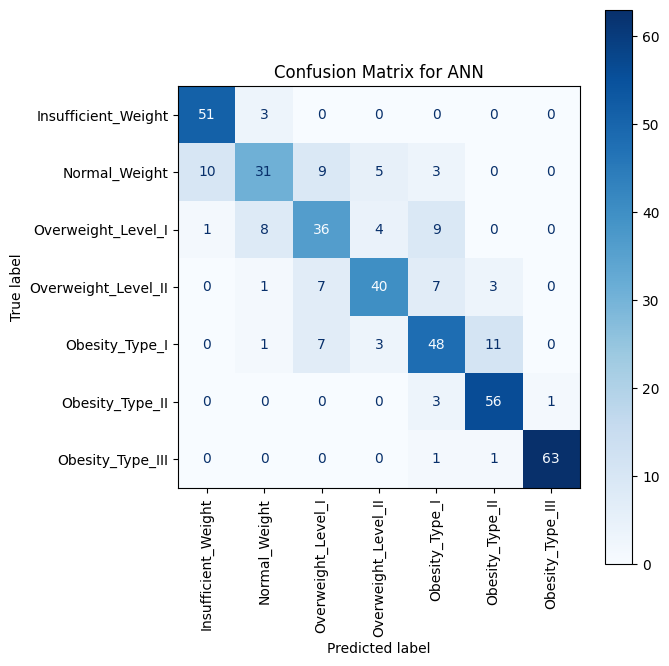

In [ ]:
# Define class names
class_names = [k for k, v in sorted(mapping.items(), key=lambda item: item[1])]

# Call the evaluation functions
evaluate_ann_model(ann_model, X_test_scaled, y_test, class_names)

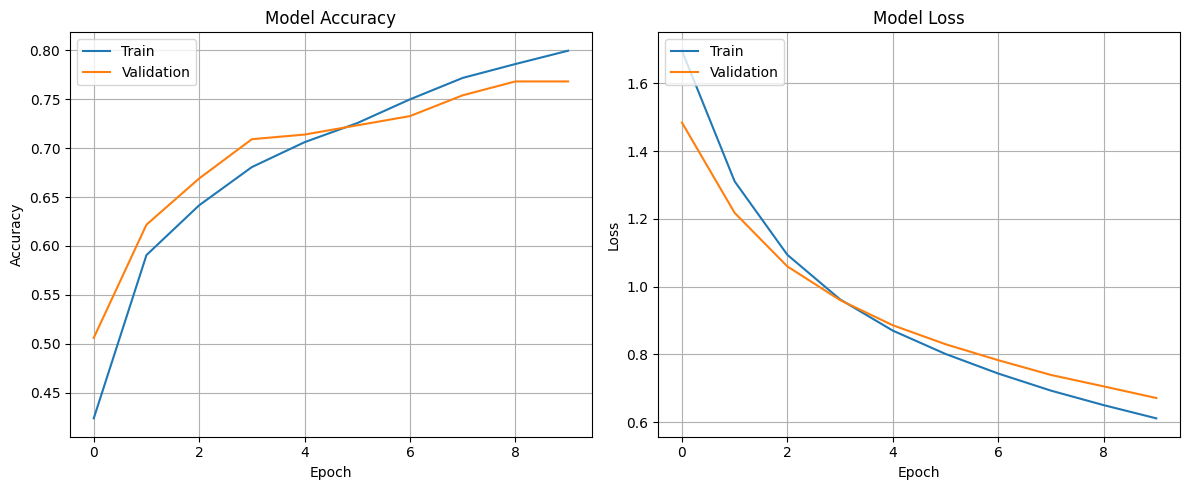

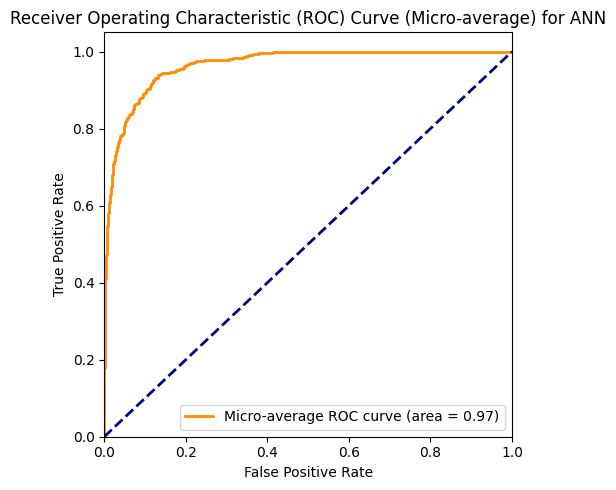

In [ ]:
# Plot the learning and the roc curves
plot_ann_learning_curve(history)
plot_ann_roc_curve(ann_model, X_test_scaled, y_test, class_names)

### Interpretation of First ANN Model

The initial ANN model achieved a moderate test accuracy of **0.7683**, with varied performance across classes, notably lower for 'Normal_Weight' and 'Overweight_Level_I'. This suggests the model is likely underfitting.

To address this, we're increasing model capacity by moving to two hidden layers, with 32 nodes in the second layer. This aims to capture more complex data patterns.

In [ ]:
print("Training the ANN with 2 hidden layers, and 32 nodes on the 2nd hidden layer:")
history, ann_model = create_and_train_ann(X_train_scaled, y_train, X_test_scaled, y_test, num_hidden_layers=2, units_per_layer=64)

Training the ANN with 2 hidden layers, and 32 nodes on the 2nd hidden layer:
--- Model Architecture ---


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,655 (14.28 KB)

 Trainable params: 3,655 (14.28 KB)

 Non-trainable params: 0 (0.00 B)



--- Model Training ---
Epoch 1: Train Acc: 0.3015, Val Acc: 0.4728, Val AUC: 0.8349, Val Precision: 0.4924, Val Recall: 0.4728
Epoch 2: Train Acc: 0.5681, Val Acc: 0.6052, Val AUC: 0.9130, Val Precision: 0.6413, Val Recall: 0.6052
Epoch 3: Train Acc: 0.6659, Val Acc: 0.7187, Val AUC: 0.9406, Val Precision: 0.7217, Val Recall: 0.7187
Epoch 4: Train Acc: 0.7464, Val Acc: 0.7707, Val AUC: 0.9536, Val Precision: 0.7720, Val Recall: 0.7707
Epoch 5: Train Acc: 0.7832, Val Acc: 0.8014, Val AUC: 0.9630, Val Precision: 0.7992, Val Recall: 0.8014
Epoch 6: Train Acc: 0.8146, Val Acc: 0.8038, Val AUC: 0.9717, Val Precision: 0.8015, Val Recall: 0.8038
Epoch 7: Train Acc: 0.8347, Val Acc: 0.8369, Val AUC: 0.9765, Val Precision: 0.8370, Val Recall: 0.8369
Epoch 8: Train Acc: 0.8620, Val Acc: 0.8369, Val AUC: 0.9820, Val Precision: 0.8369, Val Recall: 0.8369
Epoch 9: Train Acc: 0.8827, Val Acc: 0.8511, Val AUC: 0.9844, Val Precision: 0.8509, Val Recall: 0.8511
Epoch 10: Train Acc: 0.8975, Val Acc: 0


--- ANN Model Evaluation ---
Accuracy: 0.8676

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.89      0.94      0.92        54
      Normal_Weight       0.80      0.71      0.75        58
 Overweight_Level_I       0.74      0.84      0.79        58
Overweight_Level_II       0.87      0.78      0.82        58
     Obesity_Type_I       0.87      0.87      0.87        70
    Obesity_Type_II       0.89      0.95      0.92        60
   Obesity_Type_III       1.00      0.97      0.98        65

           accuracy                           0.87       423
          macro avg       0.87      0.87      0.86       423
       weighted avg       0.87      0.87      0.87       423



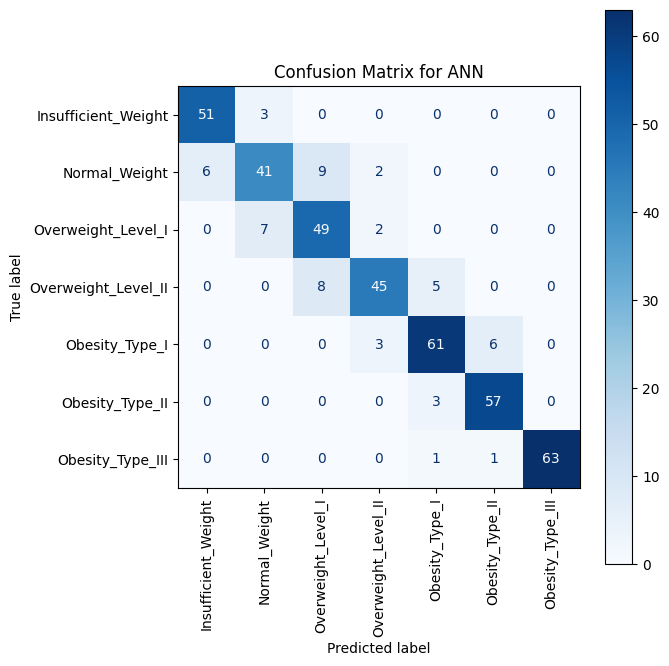

In [ ]:
# Define class names
class_names = [k for k, v in sorted(mapping.items(), key=lambda item: item[1])]

# Call the evaluation functions
evaluate_ann_model(ann_model, X_test_scaled, y_test, class_names)

### Interpretation of Second ANN Model (2 Hidden Layers)

After increasing the model complexity to two hidden layers (64 -> 32 units), the ANN model's performance significantly improved, reaching an accuracy of **0.8676**. This is a substantial gain compared to the initial single-layer model's 0.7683 accuracy, indicating that the added capacity helped the model capture more complex relationships within the data.

The classification report shows improvements across most classes, with 'Insufficient_Weight' and 'Obesity_Type_III' maintaining strong performance. However, classes like 'Normal_Weight' and 'Overweight_Level_I' still exhibit moderate recall and F1-scores, suggesting there's still room for improvement. Despite the positive step, the model might still be undertrained or lack sufficient capacity to fully differentiate all classes.

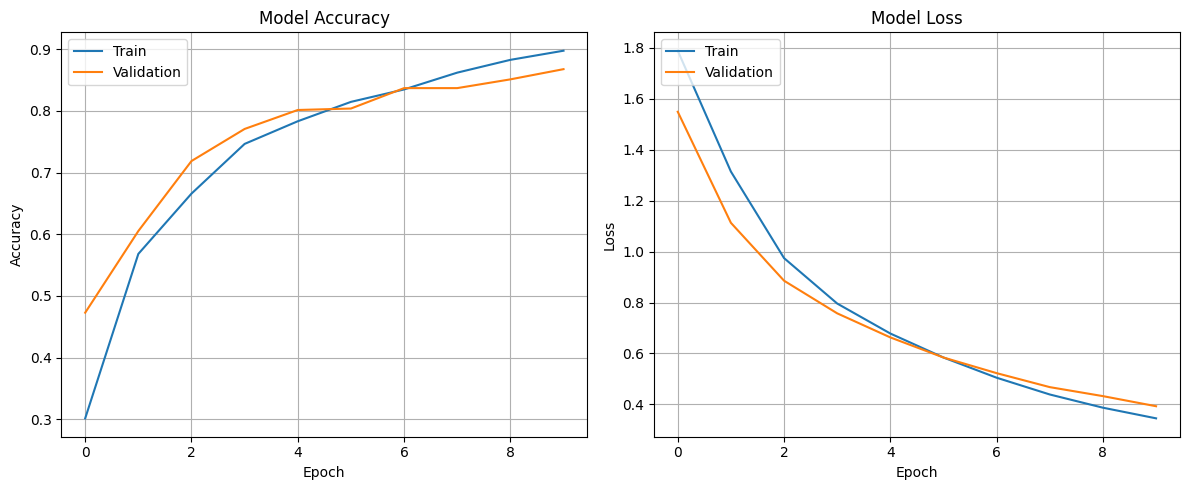

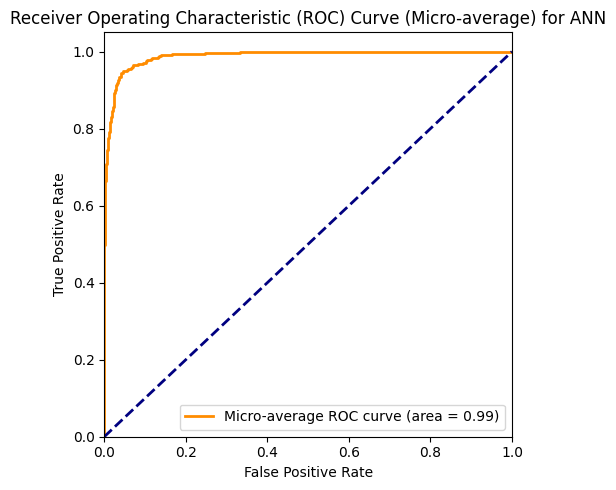

In [ ]:
# Plot the learning and the roc curves
plot_ann_learning_curve(history)
plot_ann_roc_curve(ann_model, X_test_scaled, y_test, class_names)

### Interpretation of Second ANN Model (2 Hidden Layers)

After increasing the model complexity to two hidden layers (64 -> 32 units), the ANN model's performance significantly improved, reaching an accuracy of **0.8676**. This is a substantial gain compared to the initial single-layer model's 0.7683 accuracy, indicating that the added capacity helped the model capture more complex relationships within the data.

The classification report shows improvements across most classes, with 'Insufficient_Weight' and 'Obesity_Type_III' maintaining strong performance. However, classes like 'Normal_Weight' and 'Overweight_Level_I' still exhibit moderate recall and F1-scores, suggesting there's still room for improvement. Despite the positive step, the model might still be undertrained or lack sufficient capacity to fully differentiate all classes.

### Rationale for an ANN with a limit of 50 epochs

For the last model, we notice that on the epoch 9, the validation accuracy was 84.87%, and it was 85.34% at the 10th epoch. This suggests that the metrics were still improving at the epoch 10 and that the model had not converged yet.

Therefore, because we laredy implemented the Earlystopping, we're going to increase the number of epochs to 50 and let the model continue to learn until validation performance stops improving.

In [ ]:
print("Training the ANN with 2 hidden layers, and 32 nodes on the 2nd hidden layer, and a limit of 50 epochs:")
history, ann_model = create_and_train_ann(X_train_scaled, y_train, X_test_scaled, y_test, num_hidden_layers=2, units_per_layer=64, epochs=50)

Training the ANN with 2 hidden layers, and 32 nodes on the 2nd hidden layer, and a limit of 50 epochs:
--- Model Architecture ---


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,655 (14.28 KB)

 Trainable params: 3,655 (14.28 KB)

 Non-trainable params: 0 (0.00 B)



--- Model Training ---
Epoch 1: Train Acc: 0.3063, Val Acc: 0.4468, Val AUC: 0.8427, Val Precision: 0.4613, Val Recall: 0.4468
Epoch 2: Train Acc: 0.5717, Val Acc: 0.5934, Val AUC: 0.8972, Val Precision: 0.5793, Val Recall: 0.5934
Epoch 3: Train Acc: 0.6641, Val Acc: 0.6548, Val AUC: 0.9263, Val Precision: 0.6443, Val Recall: 0.6548
Epoch 4: Train Acc: 0.7192, Val Acc: 0.7329, Val AUC: 0.9434, Val Precision: 0.7237, Val Recall: 0.7329
Epoch 5: Train Acc: 0.7660, Val Acc: 0.7707, Val AUC: 0.9554, Val Precision: 0.7657, Val Recall: 0.7707
Epoch 6: Train Acc: 0.8004, Val Acc: 0.7991, Val AUC: 0.9640, Val Precision: 0.7961, Val Recall: 0.7991
Epoch 7: Train Acc: 0.8217, Val Acc: 0.7991, Val AUC: 0.9722, Val Precision: 0.7966, Val Recall: 0.7991
Epoch 8: Train Acc: 0.8454, Val Acc: 0.8156, Val AUC: 0.9765, Val Precision: 0.8180, Val Recall: 0.8156
Epoch 9: Train Acc: 0.8614, Val Acc: 0.8345, Val AUC: 0.9799, Val Precision: 0.8360, Val Recall: 0.8345
Epoch 10: Train Acc: 0.8809, Val Acc: 0


--- ANN Model Evaluation ---
Accuracy: 0.9385

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.96      0.98        54
      Normal_Weight       0.88      0.88      0.88        58
 Overweight_Level_I       0.86      0.84      0.85        58
Overweight_Level_II       0.93      0.95      0.94        58
     Obesity_Type_I       0.95      1.00      0.97        70
    Obesity_Type_II       0.97      0.95      0.96        60
   Obesity_Type_III       0.98      0.97      0.98        65

           accuracy                           0.94       423
          macro avg       0.94      0.94      0.94       423
       weighted avg       0.94      0.94      0.94       423



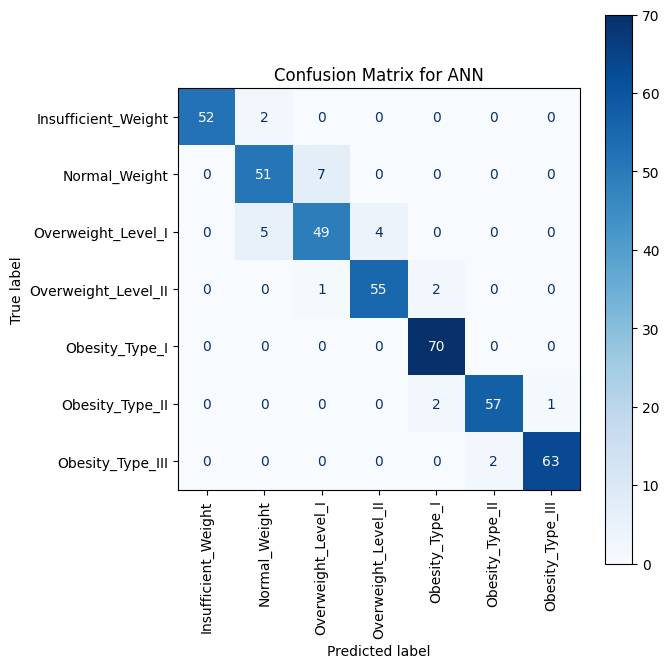

In [ ]:
# Define class names
class_names = [k for k, v in sorted(mapping.items(), key=lambda item: item[1])]

# Call the evaluation functions
evaluate_ann_model(ann_model, X_test_scaled, y_test, class_names)

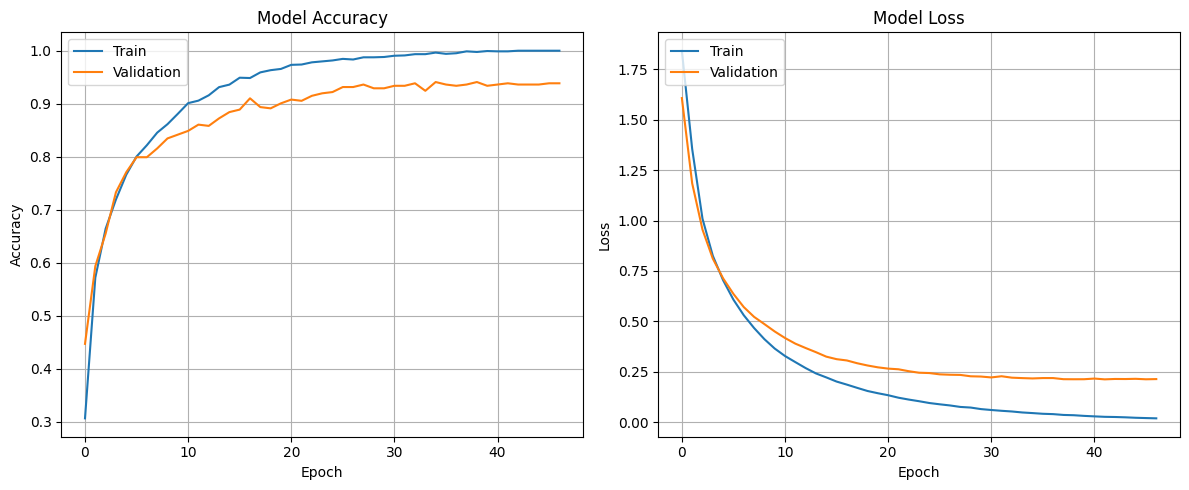

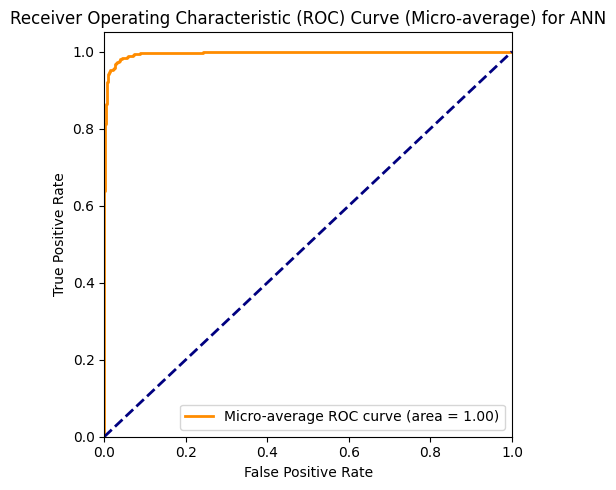

In [ ]:
# Plot the learning and the roc curves
plot_ann_learning_curve(history)
plot_ann_roc_curve(ann_model, X_test_scaled, y_test, class_names)

This ANN model (with 50 epochs) achieved a strong accuracy of **0.9385**, showing significant improvements across all classes compared to previous iterations. The high precision and recall values suggest excellent performance in classifying obesity levels.

Additionally, from epoch 10 to epoch 50 the validation accuracy jumped by 9%. This tell us that the original model was not underpowered, it was simply undertrained. However, with a training accuracy of 100%, we notice that our model is overfitting and has memorized the training dataset.

To avoid this, for the next experiment, let's reduce the learning rate. By doing so, we will allow the optimizer to find a better minimum, and reduce oscillations around the optimum. But tradeoff is that convergence will be slower.

In [ ]:
print("Training the ANN with 2 hidden layers, and 32 nodes on the 2nd hidden layer, and a limit of 50 epochs:")
history, ann_model = create_and_train_ann(X_train_scaled, y_train, X_test_scaled, y_test, num_hidden_layers=2, epochs=50, learning_rate=0.0005)

Training the ANN with 2 hidden layers, and 32 nodes on the 2nd hidden layer, and a limit of 50 epochs:
--- Model Architecture ---


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,655 (14.28 KB)

 Trainable params: 3,655 (14.28 KB)

 Non-trainable params: 0 (0.00 B)



--- Model Training ---
Epoch 1: Train Acc: 0.2749, Val Acc: 0.3286, Val AUC: 0.7436, Val Precision: 0.3311, Val Recall: 0.3286
Epoch 2: Train Acc: 0.3969, Val Acc: 0.4374, Val AUC: 0.8318, Val Precision: 0.4544, Val Recall: 0.4374
Epoch 3: Train Acc: 0.5261, Val Acc: 0.6005, Val AUC: 0.8728, Val Precision: 0.6235, Val Recall: 0.6005
Epoch 4: Train Acc: 0.6066, Val Acc: 0.6667, Val AUC: 0.9017, Val Precision: 0.6765, Val Recall: 0.6667
Epoch 5: Train Acc: 0.6611, Val Acc: 0.6974, Val AUC: 0.9207, Val Precision: 0.7006, Val Recall: 0.6974
Epoch 6: Train Acc: 0.6801, Val Acc: 0.7045, Val AUC: 0.9336, Val Precision: 0.7016, Val Recall: 0.7045
Epoch 7: Train Acc: 0.7192, Val Acc: 0.7258, Val AUC: 0.9426, Val Precision: 0.7248, Val Recall: 0.7258
Epoch 8: Train Acc: 0.7470, Val Acc: 0.7400, Val AUC: 0.9500, Val Precision: 0.7349, Val Recall: 0.7400
Epoch 9: Train Acc: 0.7767, Val Acc: 0.7565, Val AUC: 0.9563, Val Precision: 0.7514, Val Recall: 0.7565
Epoch 10: Train Acc: 0.7944, Val Acc: 0


--- ANN Model Evaluation ---
Accuracy: 0.9338

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.93      0.96      0.95        54
      Normal_Weight       0.86      0.84      0.85        58
 Overweight_Level_I       0.89      0.84      0.87        58
Overweight_Level_II       0.95      0.95      0.95        58
     Obesity_Type_I       0.92      1.00      0.96        70
    Obesity_Type_II       0.98      0.95      0.97        60
   Obesity_Type_III       1.00      0.97      0.98        65

           accuracy                           0.93       423
          macro avg       0.93      0.93      0.93       423
       weighted avg       0.93      0.93      0.93       423



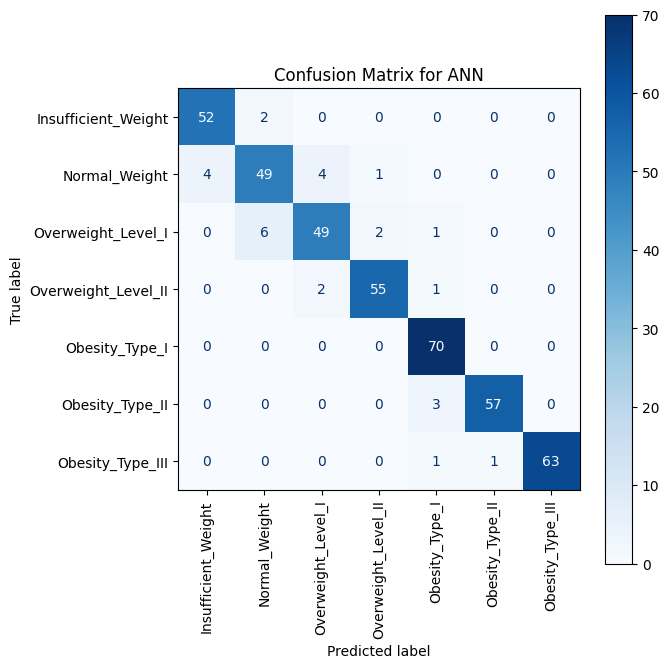

In [ ]:
# Define class names
class_names = [k for k, v in sorted(mapping.items(), key=lambda item: item[1])]

# Call the evaluation functions
evaluate_ann_model(ann_model, X_test_scaled, y_test, class_names)

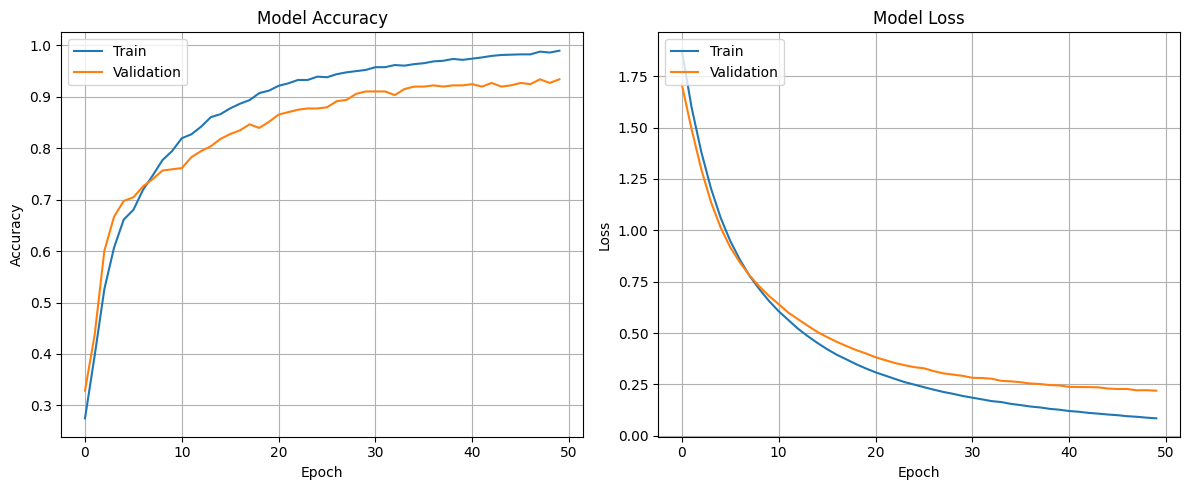

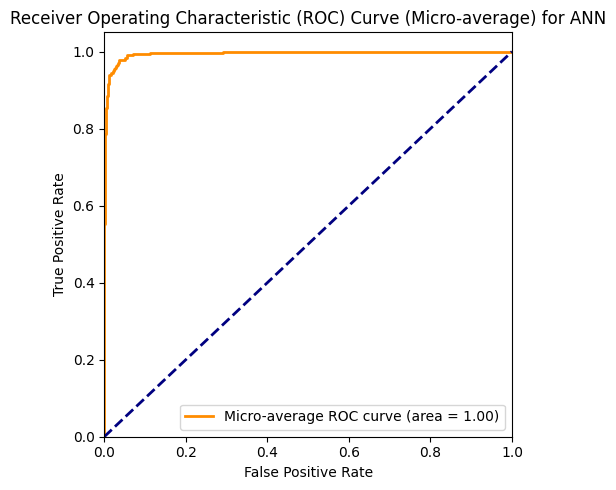

In [ ]:
# Plot the learning and the roc curves
plot_ann_learning_curve(history)
plot_ann_roc_curve(ann_model, X_test_scaled, y_test, class_names)

The lower learning rate (0.0005) successfully reduced memorization, but did not improve generalization. In fact, the accuracy decreased slightly (from 94 to 93). This means that for this architecture and dataset, the learning rate of 0.001 appears to be closer to the optimal value.

For that reaseon, we are going to create a new ANN model by increasing the number of nodes in each hidden layer in order to test this time the model capacity.

In [ ]:
print("Training the ANN with 2 hidden layers, and 128 nodes on the 1st hidden layer and 64 in the 2nd, and a limit of 50 epochs:")
history, ann_model = create_and_train_ann(X_train_scaled, y_train, X_test_scaled, y_test, num_hidden_layers=2, units_per_layer=128, epochs=50)

Training the ANN with 2 hidden layers, and 128 nodes on the 1st hidden layer and 64 in the 2nd, and a limit of 50 epochs:
--- Model Architecture ---


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,399 (44.53 KB)

 Trainable params: 11,399 (44.53 KB)

 Non-trainable params: 0 (0.00 B)



--- Model Training ---
Epoch 1: Train Acc: 0.5113, Val Acc: 0.6217, Val AUC: 0.9204, Val Precision: 0.6307, Val Recall: 0.6217
Epoch 2: Train Acc: 0.6967, Val Acc: 0.6950, Val AUC: 0.9468, Val Precision: 0.6944, Val Recall: 0.6950
Epoch 3: Train Acc: 0.7773, Val Acc: 0.7707, Val AUC: 0.9637, Val Precision: 0.7705, Val Recall: 0.7707
Epoch 4: Train Acc: 0.8341, Val Acc: 0.8085, Val AUC: 0.9743, Val Precision: 0.8105, Val Recall: 0.8085
Epoch 5: Train Acc: 0.8685, Val Acc: 0.8440, Val AUC: 0.9802, Val Precision: 0.8433, Val Recall: 0.8440
Epoch 6: Train Acc: 0.8940, Val Acc: 0.8771, Val AUC: 0.9849, Val Precision: 0.8824, Val Recall: 0.8771
Epoch 7: Train Acc: 0.9177, Val Acc: 0.8747, Val AUC: 0.9882, Val Precision: 0.8793, Val Recall: 0.8747
Epoch 8: Train Acc: 0.9372, Val Acc: 0.8960, Val AUC: 0.9906, Val Precision: 0.8969, Val Recall: 0.8960
Epoch 9: Train Acc: 0.9479, Val Acc: 0.9125, Val AUC: 0.9916, Val Precision: 0.9141, Val Recall: 0.9125
Epoch 10: Train Acc: 0.9532, Val Acc: 0


--- ANN Model Evaluation ---
Accuracy: 0.9409

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.95      0.98      0.96        54
      Normal_Weight       0.91      0.84      0.88        58
 Overweight_Level_I       0.88      0.86      0.87        58
Overweight_Level_II       0.93      0.97      0.95        58
     Obesity_Type_I       0.96      1.00      0.98        70
    Obesity_Type_II       0.97      0.95      0.96        60
   Obesity_Type_III       0.98      0.97      0.98        65

           accuracy                           0.94       423
          macro avg       0.94      0.94      0.94       423
       weighted avg       0.94      0.94      0.94       423



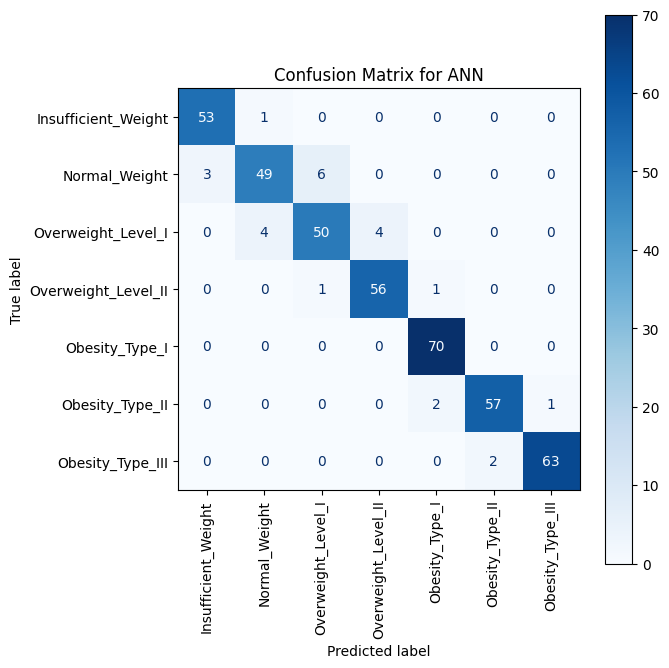

In [ ]:
# Define class names
class_names = [k for k, v in sorted(mapping.items(), key=lambda item: item[1])]

# Call the evaluation functions
evaluate_ann_model(ann_model, X_test_scaled, y_test, class_names)

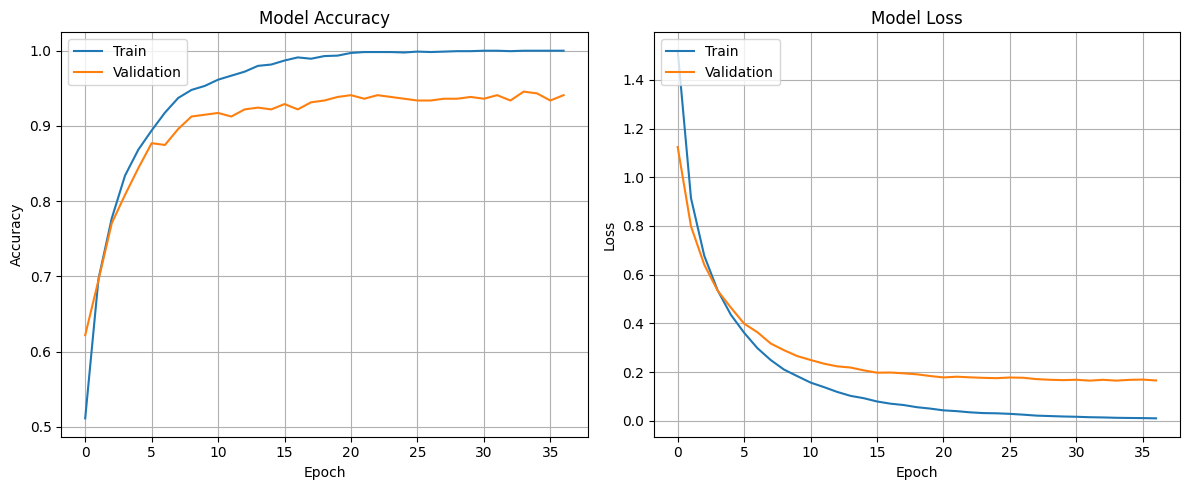

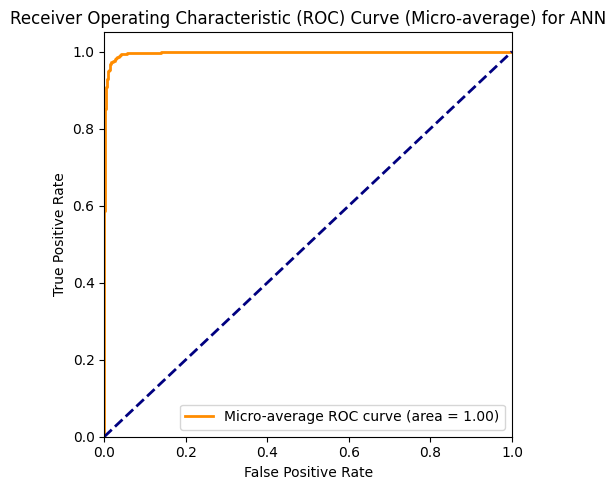

In [ ]:
# Plot the learning and the roc curves
plot_ann_learning_curve(history)
plot_ann_roc_curve(ann_model, X_test_scaled, y_test, class_names)

From the epoch 21, the validation performance remains consistently high, fluctuating around 94%. This suggests that the model has already learned most of the useful patterns, and additional epochs are not producing meaningful gains. Therefore, we are close to the performance ceiling of this architecture.

On the other hand, we notice that the AUC keeps increasing. This means the model's probability rankings continue improving even when classification accuracy appears flat. The AUC at the 37th epoch of 0.9972 is excellent!

### **Performance/Results summary table**

| Model/Approach | Hyperparameters/Settings | Dataset Splits and Standardization | Model Accuracy | Observations/Insights |
|:---------------|:-------------------------|:---------------|:-----------------------------------|:----------------------|
| **Random Forest** |||||
| RF Model 1 | `max_depth=8`, `n_estimators=300`, `max_features=None` | Train-Test (80/20), `stratify=y`, `StandardScaler` | 0.9338 | Initial Random Forest (RF) model, good performance. |
| RF Model 2 | `max_depth=12`, `n_estimators=300`, `max_features=None` | Train-Test (80/20), `stratify=y`, `StandardScaler` | **0.9480** | Improved performance with increased `max_depth`. |
| RF Model 3 | `max_depth=15`, `n_estimators=300`, `max_features=None` | Train-Test (80/20), `stratify=y`, `StandardScaler` | 0.9480 | No further improvement; model did not overfit, but performance plateaued. |
| **Artificial Neural Network (ANN)** |||||
| ANN Experiment 1 | 1 hidden layer (64 units), `epochs=10`, `learning_rate=0.001`, `batch_size=32` | Train-Test (80/20), `stratify=y`, `StandardScaler` | 0.7683 | Under-trained/under-powered. |
| ANN Experiment 2 | 2 hidden layers (64 -> 32 units), `epochs=10`, `learning_rate=0.001`, `batch_size=32` | Train-Test (80/20), `stratify=y`, `StandardScaler` | 0.8676 | Improvement, but still under-trained. |
| ANN Experiment 3 | 2 hidden layers (64 -> 32 units), `epochs=50`, `learning_rate=0.001`, `batch_size=32`, `EarlyStopping` | Train-Test (80/20), `stratify=y`, `StandardScaler` | 0.9385 | Significant improvement. High training accuracy (100%) suggests overfitting. |
| ANN Experiment 4 | 2 hidden layers (64 -> 32 units), `epochs=50`, `learning_rate=0.0005`,`batch_size=32`, `EarlyStopping` | Train-Test (80/20), `stratify=y`, `StandardScaler` | 0.9338 | Reduced overfitting, but slight decrease in test accuracy. Original learning rate (`0.001`) seems better. |
| ANN Experiment 5 | 2 hidden layers (128 -> 64 units), `epochs=50`, `learning_rate=0.001`, `batch_size=32`, `EarlyStopping` | Train-Test (80/20), `stratify=y`, `StandardScaler` | **0.9409** | Similar accuracy to best RF model. Validation AUC kept improving, suggesting good probability ranking. <br>Performance ceiling of this architecture reached.